In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Change this string to explore a different compare_model_predictions.py output.
CSV_FILE = "../sequence_to_svm_minimal/data/proteomes/paper_pddp/generated/model_comparison_latest.csv"
CSV_PATH = Path(CSV_FILE).expanduser().resolve()

# Optional location for derived outputs, plots, or exports.
OUTPUT_DIR = CSV_PATH.parent

# Add peptide sequences here to highlight their scores on the plots when present.
MARKED_PEPTIDE_SEQUENCES = [
    "SLVTKKKRFWCWQRPKYQFL",
    "SQLYPRHKHLLIKRSLRCRKC",
    "MRAKWRKKRMRRLK",
    "RSIFIKYKSKPFCEKLLSWVKS",
    "SRVPRFYWKDRLLKMKMA",
    "LPLIIFLRNRLKY",
    "KRRFNIKLWKTF",
    "RRYVRKFVLMR",
    "SRGLRYYYDKNIIHKTAGKRYVYRFV",
    "GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNM",

]
SEQUENCE_COLUMN = "sequence"

# If you want nicer default styling:
plt.style.use("seaborn-v0_8-whitegrid")


def get_marked_rows(data, sequences, sequence_col=SEQUENCE_COLUMN):
    if not sequences or sequence_col not in data.columns:
        return data.iloc[0:0]

    requested = pd.Series(sequences, dtype="string").dropna().str.strip()
    requested = requested[requested != ""].drop_duplicates()
    if requested.empty:
        return data.iloc[0:0]

    observed = data[sequence_col].astype("string").str.strip()
    return data.loc[observed.isin(requested)].copy()


def marked_scores_for_column(data, score_col):
    rows = get_marked_rows(data, MARKED_PEPTIDE_SEQUENCES)
    if rows.empty or score_col not in rows.columns:
        return rows.iloc[0:0], np.array([], dtype=float)

    scores = pd.to_numeric(rows[score_col], errors="coerce")
    rows = rows.loc[scores.notna()].copy()
    return rows, scores.loc[scores.notna()].to_numpy(dtype=float)


def expand_xlim_for_values(xlim, values, pad_fraction=0.05):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not values.size:
        return xlim

    lo = min(xlim[0], float(values.min()))
    hi = max(xlim[1], float(values.max()))
    pad = pad_fraction * (hi - lo) if hi > lo else 1.0
    return (lo - pad, hi + pad)


def mark_peptide_scores(ax, x_values, label, color="black"):
    if len(x_values) == 0:
        return

    ymin, ymax = ax.get_ylim()
    marker_y = ymin + 0.04 * (ymax - ymin)
    line_top = ymin + 0.12 * (ymax - ymin)
    ax.vlines(
        x_values,
        ymin,
        line_top,
        colors=color,
        linestyles=":",
        linewidth=1,
        alpha=0.9,
        zorder=4,
    )
    ax.scatter(
        x_values,
        np.full(len(x_values), marker_y),
        marker="D",
        s=36,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        label=label,
        zorder=5,
    )



In [35]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"Comparison CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

score_cols = [c for c in df.columns if c.endswith("_score_z")]
models = [c[: -len("_score_z")] for c in score_cols]

print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df):,}")
print(f"Models with z-scores: {models}")


Loaded: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\proteomes\paper_pddp\generated\model_comparison_latest.csv
Rows: 139,409
Models with z-scores: ['ESM-only']


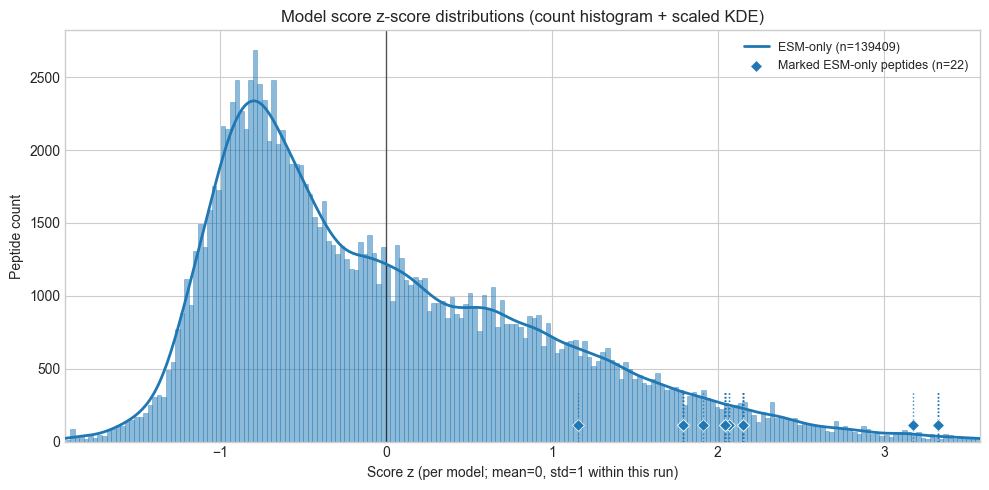

In [36]:
# Z-score distributions: count histogram + KDE scaled to peptide count per bin
from scipy.stats import gaussian_kde

vals = []
for c in score_cols:
    v = pd.to_numeric(df[c], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size:
        vals.append(v)

if not vals:
    raise ValueError("No finite z-scores found in the CSV.")

all_v = np.concatenate(vals)
lo = float(np.nanpercentile(all_v, 1))
hi = float(np.nanpercentile(all_v, 99))
pad = 0.05 * (hi - lo) if hi > lo else 1.0
xlim = (lo - pad, hi + pad)

marked_z_values = []
for c in score_cols:
    _, marked_values = marked_scores_for_column(df, c)
    marked_z_values.extend(marked_values)
xlim = expand_xlim_for_values(xlim, marked_z_values)

n_bins = 200
bins = np.linspace(xlim[0], xlim[1], n_bins + 1)
bin_width = bins[1] - bins[0]

curve_entries = []
for model, col in zip(models, score_cols):
    v = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size >= 5:
        curve_entries.append((model, col, v))

if not curve_entries:
    raise ValueError("No model with >=5 finite z-scores.")

n_curves = len(curve_entries)
colors = plt.cm.tab10(np.linspace(0, 1, max(n_curves, 10)))[:n_curves]
xs = np.linspace(xlim[0], xlim[1], 512)

plt.figure(figsize=(10, 5))
for i, (model, col, v) in enumerate(curve_entries):
    c = colors[i]
    plt.hist(
        v,
        bins=bins,
        density=False,
        histtype="bar",
        linewidth=0.5,
        edgecolor=c,
        facecolor=c,
        alpha=0.5,
        zorder=1,
    )

for i, (model, col, v) in enumerate(curve_entries):
    c = colors[i]
    try:
        d = gaussian_kde(v)(xs) * len(v) * bin_width
    except np.linalg.LinAlgError:
        continue
    plt.plot(
        xs,
        d,
        color=c,
        linewidth=2,
        label=f"{model} (n={len(v)})",
        zorder=3,
    )

plt.axvline(0.0, color="black", linewidth=1, alpha=0.6, zorder=2)
plt.xlim(*xlim)
ax = plt.gca()
for i, (model, col, v) in enumerate(curve_entries):
    _, marked_values = marked_scores_for_column(df, col)
    mark_peptide_scores(
        ax,
        marked_values,
        f"Marked {model} peptides (n={len(marked_values)})",
        color=colors[i],
    )
plt.xlabel("Score z (per model; mean=0, std=1 within this run)")
plt.ylabel("Peptide count")
plt.title("Model score z-score distributions (count histogram + scaled KDE)")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


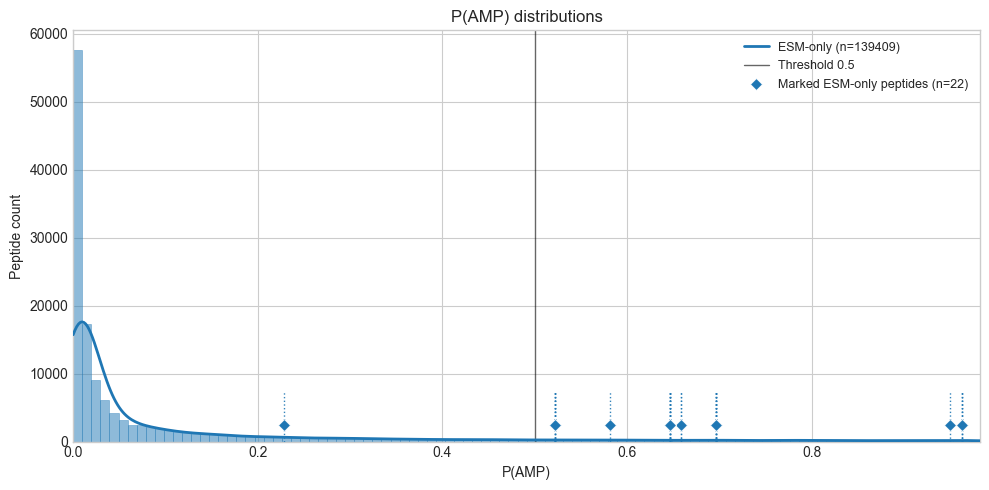

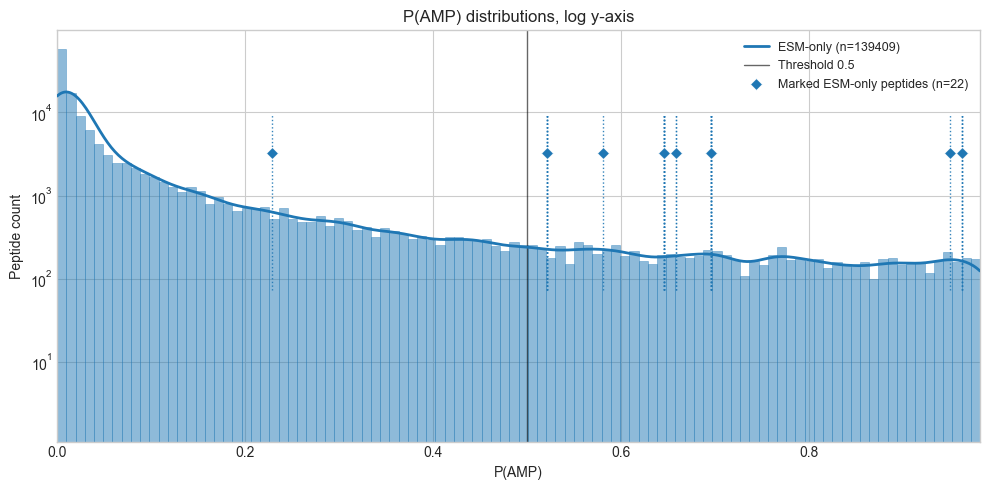

In [37]:
# P(AMP) distributions: linear x and log-y (count) views
from scipy.stats import gaussian_kde

prob_cols = sorted(c for c in df.columns if c.endswith("_prob_AMP"))
prob_models = [c[: -len("_prob_AMP")] for c in prob_cols]

if not prob_cols:
    raise ValueError("No *_prob_AMP columns found in the CSV.")

vals_prob = []
for c in prob_cols:
    v = pd.to_numeric(df[c], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size:
        vals_prob.append(v)

if not vals_prob:
    raise ValueError("No finite P(AMP) values found in the CSV.")

all_prob = np.concatenate(vals_prob)
lo_p = max(0.0, float(np.nanpercentile(all_prob, 1)))
hi_p = min(1.0, float(np.nanpercentile(all_prob, 99)))
pad_p = 0.05 * (hi_p - lo_p) if hi_p > lo_p else 0.05
xlim_prob = (max(0.0, lo_p - pad_p), min(1.0, hi_p + pad_p))

marked_prob_values = []
for c in prob_cols:
    _, marked_values = marked_scores_for_column(df, c)
    marked_prob_values.extend(marked_values)
xlim_prob = expand_xlim_for_values(xlim_prob, marked_prob_values, pad_fraction=0.02)
xlim_prob = (max(0.0, xlim_prob[0]), min(1.0, xlim_prob[1]))

n_bins_prob = 100
bins_prob = np.linspace(xlim_prob[0], xlim_prob[1], n_bins_prob + 1)
bin_width_prob = bins_prob[1] - bins_prob[0]

curve_entries_prob = []
for model, col in zip(prob_models, prob_cols):
    v = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size >= 5:
        curve_entries_prob.append((model, col, v))

if not curve_entries_prob:
    raise ValueError("No model with >=5 finite P(AMP) values.")

n_curves_prob = len(curve_entries_prob)
colors_prob = plt.cm.tab10(np.linspace(0, 1, max(n_curves_prob, 10)))[:n_curves_prob]
xs_prob = np.linspace(xlim_prob[0], xlim_prob[1], 512)


def _plot_p_amp_panel(*, title, xlim, bins, xs, bin_width, log_y=False):
    plt.figure(figsize=(10, 5))
    for i, (model, col, v) in enumerate(curve_entries_prob):
        c = colors_prob[i]
        plt.hist(
            v,
            bins=bins,
            density=False,
            histtype="bar",
            linewidth=0.5,
            edgecolor=c,
            facecolor=c,
            alpha=0.5,
            zorder=1,
        )

    for i, (model, col, v) in enumerate(curve_entries_prob):
        c = colors_prob[i]
        try:
            d = gaussian_kde(v)(xs) * len(v) * bin_width
        except np.linalg.LinAlgError:
            continue
        if log_y:
            d = np.maximum(d, 1e-3)
        plt.plot(xs, d, color=c, linewidth=2, label=f"{model} (n={len(v)})", zorder=3)

    plt.axvline(0.5, color="black", linewidth=1, alpha=0.6, zorder=2, label="Threshold 0.5")
    plt.xlim(*xlim)
    if log_y:
        plt.yscale("log")
    ax = plt.gca()
    for i, (model, col, _v) in enumerate(curve_entries_prob):
        _, marked_values = marked_scores_for_column(df, col)
        mark_peptide_scores(
            ax,
            marked_values,
            f"Marked {model} peptides (n={len(marked_values)})",
            color=colors_prob[i],
        )
    plt.xlabel("P(AMP)")
    plt.ylabel("Peptide count")
    plt.title(title)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()


_plot_p_amp_panel(
    title="P(AMP) distributions",
    xlim=xlim_prob,
    bins=bins_prob,
    xs=xs_prob,
    bin_width=bin_width_prob,
)
_plot_p_amp_panel(
    title="P(AMP) distributions, log y-axis",
    xlim=xlim_prob,
    bins=bins_prob,
    xs=xs_prob,
    bin_width=bin_width_prob,
    log_y=True,
)


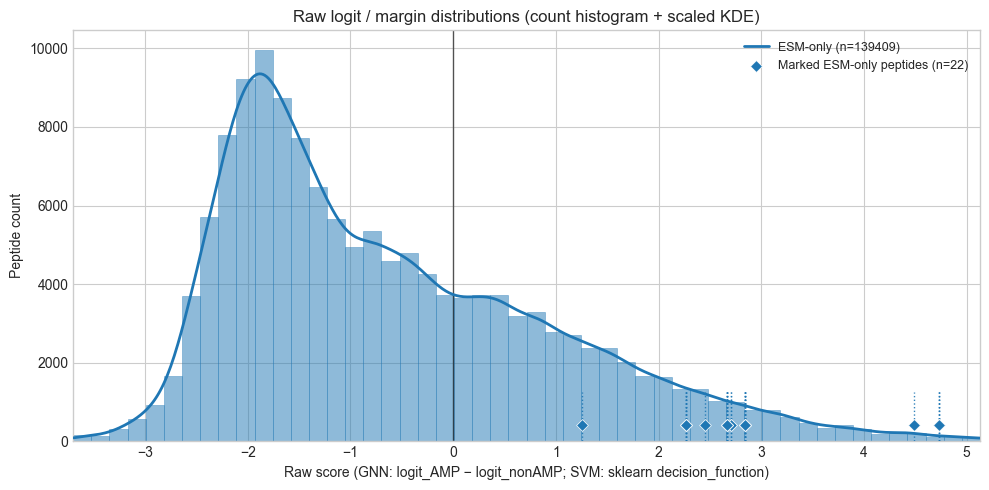

In [38]:
# Raw classifier scores: count histogram + KDE scaled to peptide count per bin
margin_cols = sorted(c for c in df.columns if c.endswith("_logit_margin"))
vals_raw = []
for c in margin_cols:
    v = pd.to_numeric(df[c], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size:
        vals_raw.append(v)
if "SVM_distance" in df.columns:
    v = pd.to_numeric(df["SVM_distance"], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size:
        vals_raw.append(v)

if not vals_raw:
    raise ValueError("No finite raw scores found (_logit_margin or SVM_distance).")

all_raw = np.concatenate(vals_raw)
lo_r = float(np.nanpercentile(all_raw, 1))
hi_r = float(np.nanpercentile(all_raw, 99))
pad_r = 0.05 * (hi_r - lo_r) if hi_r > lo_r else 1.0
xlim_raw = (lo_r - pad_r, hi_r + pad_r)

marked_raw_values = []
for col in margin_cols:
    _, marked_values = marked_scores_for_column(df, col)
    marked_raw_values.extend(marked_values)
if "SVM_distance" in df.columns:
    _, marked_values = marked_scores_for_column(df, "SVM_distance")
    marked_raw_values.extend(marked_values)
xlim_raw = expand_xlim_for_values(xlim_raw, marked_raw_values)

# Histogram + KDE on top (same colors); SVM dashed
from scipy.stats import gaussian_kde

n_bins_raw = 50
bins_raw = np.linspace(xlim_raw[0], xlim_raw[1], n_bins_raw + 1)
bin_width_raw = bins_raw[1] - bins_raw[0]

gnn_entries = []
for col in margin_cols:
    v = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy(dtype=float)
    if v.size >= 5:
        gnn_entries.append((col.replace("_logit_margin", ""), col, v))

svm_entry = None
if "SVM_distance" in df.columns:
    v_svm = pd.to_numeric(df["SVM_distance"], errors="coerce").dropna().to_numpy(dtype=float)
    if v_svm.size >= 5:
        svm_entry = ("SVM decision_function", "SVM_distance", v_svm)

xs_r = np.linspace(xlim_raw[0], xlim_raw[1], 512)
n_gnn = len(gnn_entries)
colors_gnn = plt.cm.tab10(np.linspace(0, 1, max(n_gnn, 10)))[:n_gnn]
svm_color = "#444444"

plt.figure(figsize=(10, 5))
for i, (name, col, v) in enumerate(gnn_entries):
    c = colors_gnn[i]
    plt.hist(
        v,
        bins=bins_raw,
        density=False,
        histtype="bar",
        linewidth=0.5,
        edgecolor=c,
        facecolor=c,
        alpha=0.5,
        zorder=1,
    )

if svm_entry is not None:
    _, _, v_svm = svm_entry
    plt.hist(
        v_svm,
        bins=bins_raw,
        density=False,
        histtype="bar",
        linewidth=0.5,
        edgecolor=svm_color,
        facecolor=svm_color,
        alpha=0.5,
        zorder=1,
    )

for i, (name, col, v) in enumerate(gnn_entries):
    c = colors_gnn[i]
    try:
        d = gaussian_kde(v)(xs_r) * len(v) * bin_width_raw
    except np.linalg.LinAlgError:
        continue
    plt.plot(
        xs_r,
        d,
        color=c,
        linewidth=2,
        label=f"{name} (n={len(v)})",
        zorder=3,
    )

if svm_entry is not None:
    name, col, v_svm = svm_entry
    try:
        d_svm = gaussian_kde(v_svm)(xs_r) * len(v_svm) * bin_width_raw
    except np.linalg.LinAlgError:
        d_svm = None
    if d_svm is not None:
        plt.plot(
            xs_r,
            d_svm,
            color=svm_color,
            linewidth=2,
            label=f"{name} (n={len(v_svm)})",
            zorder=3,
        )

plt.axvline(0.0, color="black", linewidth=1, alpha=0.6, zorder=2)
plt.xlim(*xlim_raw)
ax = plt.gca()
for i, (name, col, v) in enumerate(gnn_entries):
    _, marked_values = marked_scores_for_column(df, col)
    mark_peptide_scores(
        ax,
        marked_values,
        f"Marked {name} peptides (n={len(marked_values)})",
        color=colors_gnn[i],
    )
if svm_entry is not None:
    name, col, v_svm = svm_entry
    _, marked_values = marked_scores_for_column(df, col)
    mark_peptide_scores(
        ax,
        marked_values,
        f"Marked {name} peptides (n={len(marked_values)})",
        color=svm_color,
    )
plt.xlabel("Raw score (GNN: logit_AMP − logit_nonAMP; SVM: sklearn decision_function)")
plt.ylabel("Peptide count")
plt.title("Raw logit / margin distributions (count histogram + scaled KDE)")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()
